In [8]:
!git clone https://github.com/JusticeZzy/FunduSegmenter.git

%cd FunduSegmenter

d:\Projects\College\Rabcl\Segementation\FunduSegmenter


fatal: destination path 'FunduSegmenter' already exists and is not an empty directory.


In [9]:
!python --version

Python 3.11.5


In [10]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [11]:
import torch

ckpt = torch.load(
    r"D:\Projects\College\Rabcl\FunduSegmenter_CroppedImage.pth",
    map_location="cpu",
    weights_only=False
)

print(f"Checkpoint type: {type(ckpt)}")

if isinstance(ckpt, dict):
    print("\nCheckpoint keys:")
    for key in ckpt.keys():
        print(f"- {key}")

Checkpoint type: <class 'dict'>

Checkpoint keys:
- model
- optimizer
- epoch


In [12]:
import torch

from model.fundusegmenter import FunduSegmenter
from model.modules.vit import VisionTransformer
from model.modules.segmenter_decoder import SegmenterDecoder
from model.modules.adapters import PreAdapter, PostAdapter

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

image_size = 224
output_channel = 3
norm = "bn"

# -----------------------------
# Pre-adapter
# -----------------------------
pre_adapter = PreAdapter(
    input_channel=3,
    mid_channel=64,
    norm=norm
)

# -----------------------------
# RETFound ViT encoder
# -----------------------------
encoder = VisionTransformer(
    image_size=(224, 224),
    patch_size=16,
    n_layers=24,
    d_model=1024,
    d_ff=4096,
    n_heads=16,
    n_cls=1000,
    dropout=0.0,
    drop_path_rate=0.0,
    distilled=False,
    channels=3,
)

# -----------------------------
# Segmenter decoder
# -----------------------------
decoder = SegmenterDecoder(
    n_cls=output_channel,
    patch_size=16,
    d_encoder=1024,
    n_layers=2,
    n_heads=16,
    d_model=1024,
    d_ff=4096,
    drop_path_rate=0.0,
    dropout=0.1,
)

# -----------------------------
# Post-adapter
# -----------------------------
post_adapter = PostAdapter(
    input_channel=output_channel,
    mid_channel=64,
    output_channel=output_channel,
    norm=norm
)

# -----------------------------
# FunduSegmenter
# -----------------------------
model = FunduSegmenter(
    pre_adapter=pre_adapter,
    encoder=encoder,
    decoder=decoder,
    post_adapter=post_adapter
)

print("Model constructed successfully.")
print("Device:", device)

c:\Users\DARSHAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model constructed successfully.
Device: cuda


In [13]:
CHECKPOINT_PATH = (
    r"D:\Projects\College\Rabcl\FunduSegmenter_CroppedImage.pth"
)

print("Loading checkpoint...")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint keys:", checkpoint.keys())

checkpoint_model = checkpoint["model"]

msg = model.load_state_dict(
    checkpoint_model,
    strict=True
)

print("✅ FunduSegmenter weights loaded successfully")
print(msg)

Loading checkpoint...
Checkpoint keys: dict_keys(['model', 'optimizer', 'epoch'])
✅ FunduSegmenter weights loaded successfully
<All keys matched successfully>


In [14]:
model.to(device)
model.eval()

print("✅ Model moved to:", device)

✅ Model moved to: cuda


In [15]:
import torch
from torch.nn import functional as F

from model.baselines.dunet import DUNet

DUNET_WEIGHTS = r"D:\Projects\College\Rabcl\DUNet_OD_CentreCrop_pretrained.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dunet = DUNet(
    input_channel=3,
    output_channel=2,
    base_channel=32
)

checkpoint = torch.load(
    DUNET_WEIGHTS,
    map_location="cpu",
    weights_only=False
)

dunet.load_state_dict(
    checkpoint["model"],
    strict=True
)

dunet = dunet.to(device)
dunet.eval()

print("✅ DUNet loaded")
print("Device:", device)

✅ DUNet loaded
Device: cuda


In [43]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

manifest = pd.read_csv(
    r"D:\Projects\College\Rabcl\BRSET_first_15_bilateral_patients_30_images_manifest.csv"
)

row = manifest.iloc[1]

image_path = os.path.join(
    r"D:\Projects\College\Rabcl\BRSET_sample",
    row["source_image"]
)

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(image_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image:", row["source_image"])
print("Shape:", img_rgb.shape)

Image: img00002.jpg
Shape: (874, 951, 3)


In [44]:
from utils.transform import validation_transform

transform = validation_transform(image_size=256)

transform_image, transform_both = transform

transformed = transform_image(image=img_rgb)
x = transformed["image"]

transformed = transform_both(image=x)
x = transformed["image"]

x = x.unsqueeze(0).to(device)

print("DUNet input:", x.shape)
print("dtype:", x.dtype)

DUNet input: torch.Size([1, 3, 256, 256])
dtype: torch.float32


In [45]:
with torch.no_grad():
    y_pred = dunet(x)

print("Raw DUNet output:", y_pred.shape)

y_pred = F.interpolate(
    y_pred,
    size=(img_rgb.shape[0], img_rgb.shape[1]),
    mode="bicubic"
)

y_pred = torch.argmax(
    torch.softmax(y_pred, dim=1),
    dim=1
)

dunet_mask = y_pred.squeeze().cpu().numpy().astype(np.uint8)

print("DUNet mask:", dunet_mask.shape)
print("Unique values:", np.unique(dunet_mask))

Raw DUNet output: torch.Size([1, 2, 256, 256])
DUNet mask: (874, 951)
Unique values: [0 1]


In [47]:
min_area_ratio = 0.01
max_area_ratio = 0.30

# Convert to 0/255 exactly as official code
if dunet_mask.max() <= 1:
    dunet_mask = (dunet_mask * 255).astype(np.uint8)

contours, _ = cv2.findContours(
    dunet_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

best_circularity = -1
best_contour = None

H, W = img_rgb.shape[:2]

for contour in contours:

    area = cv2.contourArea(contour)

    area_ratio = area / (H * W)

    if area_ratio < min_area_ratio or area_ratio > max_area_ratio:
        continue

    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        circularity = 0
    else:
        circularity = (
            4 * np.pi * area /
            (perimeter * perimeter)
        )

    if circularity > best_circularity:
        best_circularity = circularity
        best_contour = contour

if best_contour is None:
    print("⚠️ No contour passed area filtering.")
    best_contour = max(contours, key=cv2.contourArea)

(x, y), radius = cv2.minEnclosingCircle(best_contour)

centre = (int(x), int(y))

print("✅ OD centre:", centre)
print("Radius:", radius)
print("Best circularity:", best_circularity)

Number of contours: 1
✅ OD centre: (186, 429)
Radius: 85.18000793457031
Best circularity: 0.8935314198992371


OD centre: (186, 429)
Square crop: (0, 29, 800, 829)
Crop size: 800 x 800


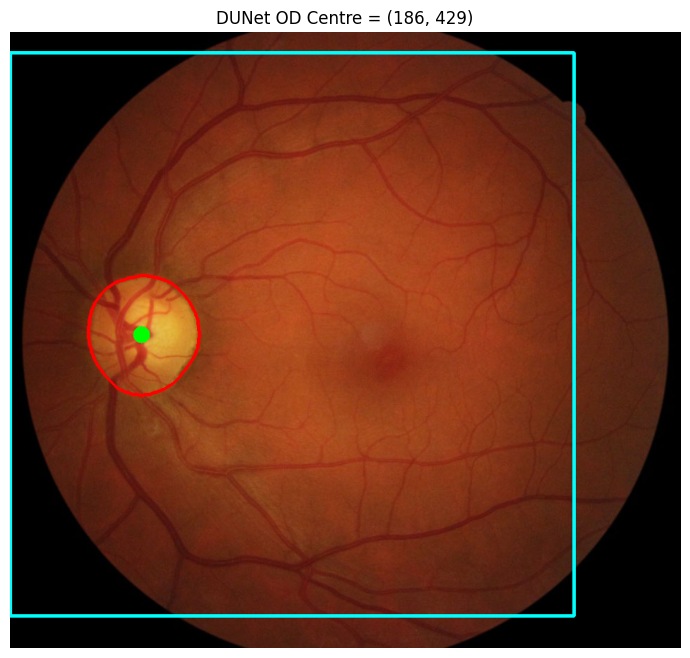

In [48]:
overlay = img_rgb.copy()

# Draw DUNet contour
cv2.drawContours(
    overlay,
    [best_contour],
    -1,
    (255, 0, 0),
    3
)

# Draw centre
cv2.circle(
    overlay,
    centre,
    12,
    (0, 255, 0),
    -1
)

# --------------------------------------------------
# Draw a TRUE 800 x 800 square crop boundary
# while keeping the entire square inside the image
# --------------------------------------------------

cx, cy = centre

crop_size = 800
half = crop_size // 2

img_h, img_w = img_rgb.shape[:2]

# Initial square centered on the detected OD
left = cx - half * 2
top = cy - half
right = left + crop_size
bottom = top + crop_size

# Shift horizontally if the square exceeds image bounds
if left < 0:
    left = 0
    right = crop_size

if right > img_w:
    right = img_w
    left = img_w - crop_size

# Shift vertically if the square exceeds image bounds
if top < 0:
    top = 0
    bottom = crop_size

if bottom > img_h:
    bottom = img_h
    top = img_h - crop_size

# Draw the corrected square
cv2.rectangle(
    overlay,
    (left, top),
    (right - 1, bottom - 1),
    (0, 255, 255),
    3
)

print("OD centre:", (cx, cy))
print("Square crop:", (left, top, right, bottom))
print("Crop size:", right - left, "x", bottom - top)

plt.figure(figsize=(10, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title(f"DUNet OD Centre = ({cx}, {cy})")
plt.show()

In [49]:
# ============================================================
# DUNet OUTPUT -> BINARY OD MASK
# ============================================================

# dunet_mask contains:
#   0 = background
#   1 = OD
#
# Convert directly to:
#   0   = black background
#   255 = white OD

dunet_od_mask = np.where(
    dunet_mask > 0,
    255,
    0
).astype(np.uint8)

print("DUNet OD mask shape:", dunet_od_mask.shape)
print("Unique values:", np.unique(dunet_od_mask))

DUNet OD mask shape: (874, 951)
Unique values: [  0 255]


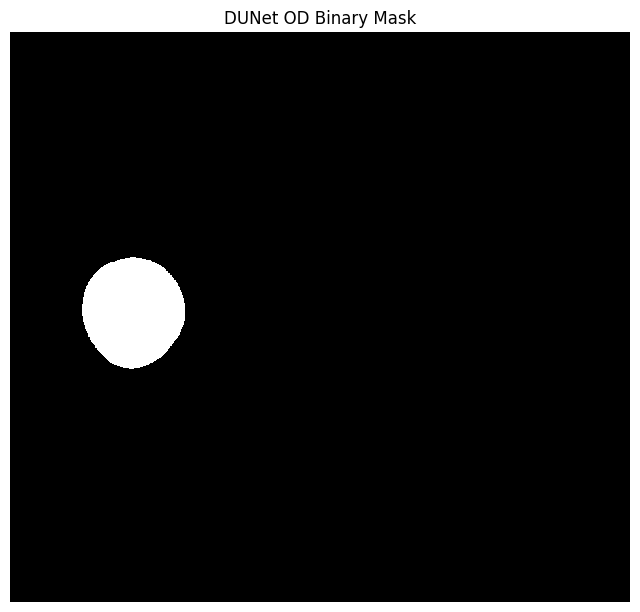

In [50]:
plt.figure(figsize=(8, 8))

plt.imshow(
    dunet_od_mask,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest"
)

plt.title("DUNet OD Binary Mask")
plt.axis("off")

plt.show()

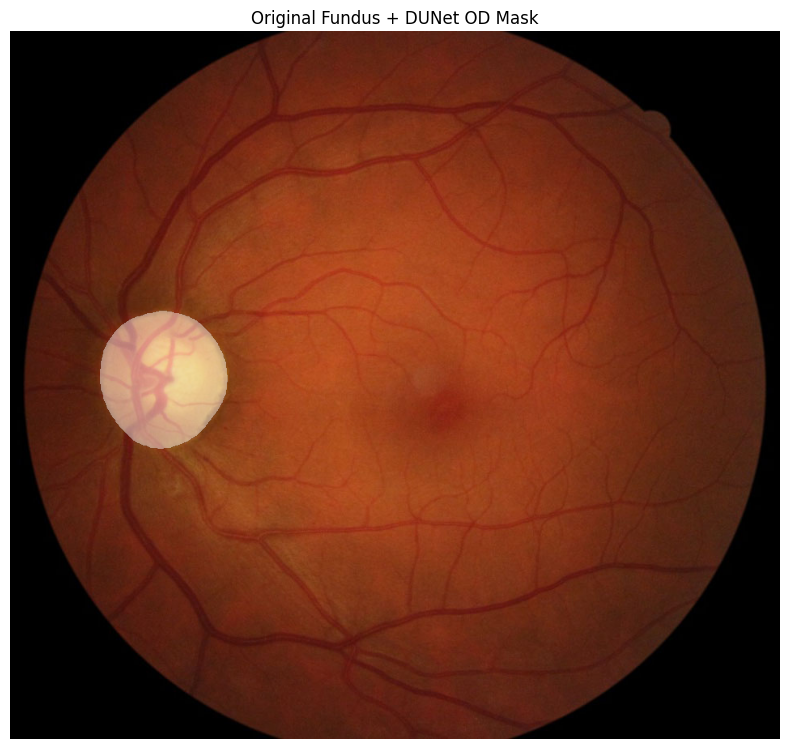

In [51]:
# ============================================================
# DUNet OD MASK OVERLAY ON ORIGINAL FUNDUS
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Original fundus as background
ax.imshow(img_rgb)

# Create transparent overlay
overlay = np.zeros(
    (*dunet_od_mask.shape, 4),
    dtype=np.float32
)

# OD pixels
od_pixels = dunet_od_mask == 255

# White OD mask
overlay[od_pixels, 0] = 1.0
overlay[od_pixels, 1] = 1.0
overlay[od_pixels, 2] = 1.0

# Transparency
overlay[od_pixels, 3] = 0.45

# Overlay on original fundus
ax.imshow(overlay)

ax.set_title("Original Fundus + DUNet OD Mask")
ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
def centre_crop_with_validity(
    centre,
    image_original,
    crop_size=800
):
    """
    Create an exactly crop_size x crop_size crop centred on the OD.

    Returns:
        cropped_image : 800x800x3
        valid_mask    : 800x800
                       1 = original image pixel
                       0 = artificial padding
    """

    cx, cy = centre

    h, w = image_original.shape[:2]
    half = crop_size // 2

    # Desired crop in ORIGINAL image coordinates
    left = cx - half
    top = cy - half
    right = left + crop_size
    bottom = top + crop_size

    # --------------------------------------------------
    # Create black-padded crop
    # --------------------------------------------------

    cropped_image = np.zeros(
        (crop_size, crop_size, 3),
        dtype=np.uint8
    )

    # --------------------------------------------------
    # Valid region in original image
    # --------------------------------------------------

    src_left = max(left, 0)
    src_top = max(top, 0)

    src_right = min(right, w)
    src_bottom = min(bottom, h)

    # --------------------------------------------------
    # Corresponding destination coordinates
    # --------------------------------------------------

    dst_left = src_left - left
    dst_top = src_top - top

    dst_right = dst_left + (src_right - src_left)
    dst_bottom = dst_top + (src_bottom - src_top)

    # --------------------------------------------------
    # Copy real image pixels
    # --------------------------------------------------

    cropped_image[
        dst_top:dst_bottom,
        dst_left:dst_right
    ] = image_original[
        src_top:src_bottom,
        src_left:src_right
    ]

    # --------------------------------------------------
    # Validity mask
    # --------------------------------------------------

    valid_mask = np.zeros(
        (crop_size, crop_size),
        dtype=np.uint8
    )

    valid_mask[
        dst_top:dst_bottom,
        dst_left:dst_right
    ] = 1

    return cropped_image, valid_mask

In [22]:
cropped_img, crop_valid = centre_crop_with_validity(
    centre=centre,
    image_original=img_rgb,
    crop_size=800
)

print("Original:", img_rgb.shape)
print("Centre:", centre)
print("Crop:", cropped_img.shape)
print("Valid pixels:", crop_valid.sum())
print("Padded pixels:", (crop_valid == 0).sum())

Original: (874, 951, 3)
Centre: (190, 406)
Crop: (800, 800, 3)
Valid pixels: 472000
Padded pixels: 168000


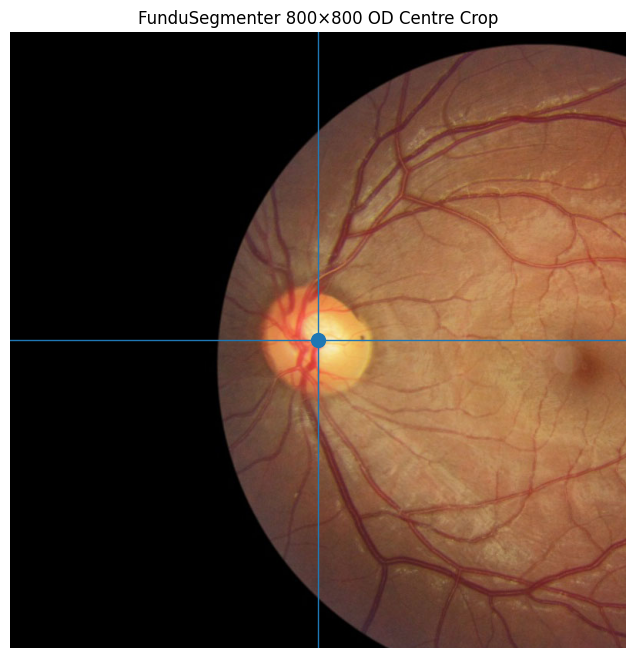

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cropped_img)

plt.axvline(400, linewidth=1)
plt.axhline(400, linewidth=1)
plt.scatter([400], [400], s=100)

plt.title("FunduSegmenter 800×800 OD Centre Crop")
plt.axis("off")
plt.show()

In [24]:
from utils.transform import validation_transform

# Official FunduSegmenter input size
image_size = 224

transform_image, transform_both = validation_transform(image_size)

# Apply exactly the same transformation used by test.py
transformed = transform_image(image=cropped_img)

model_input = transformed["image"]

print("Crop:", cropped_img.shape)
print("Model input:", model_input.shape)
print("dtype:", model_input.dtype)
print("min:", model_input.min().item())
print("max:", model_input.max().item())

Crop: (800, 800, 3)
Model input: (224, 224, 3)
dtype: float32
min: -2.1179039478302
max: 2.1804091930389404


In [25]:
model.eval()

x = torch.from_numpy(model_input).permute(2, 0, 1).unsqueeze(0).float().to(device)

print("Input to FunduSegmenter:", x.shape)
print("dtype:", x.dtype)
print("device:", x.device)

with torch.no_grad():
    output = model(x)

print("Output type:", type(output))
print("Output shape:", output.shape)

Input to FunduSegmenter: torch.Size([1, 3, 224, 224])
dtype: torch.float32
device: cuda:0
Output type: <class 'torch.Tensor'>
Output shape: torch.Size([1, 3, 224, 224])


In [26]:
pred = torch.argmax(output, dim=1)

pred = pred.squeeze(0).cpu().numpy()

print("Prediction shape:", pred.shape)
print("Unique classes:", np.unique(pred))

Prediction shape: (224, 224)
Unique classes: [0 1 2]


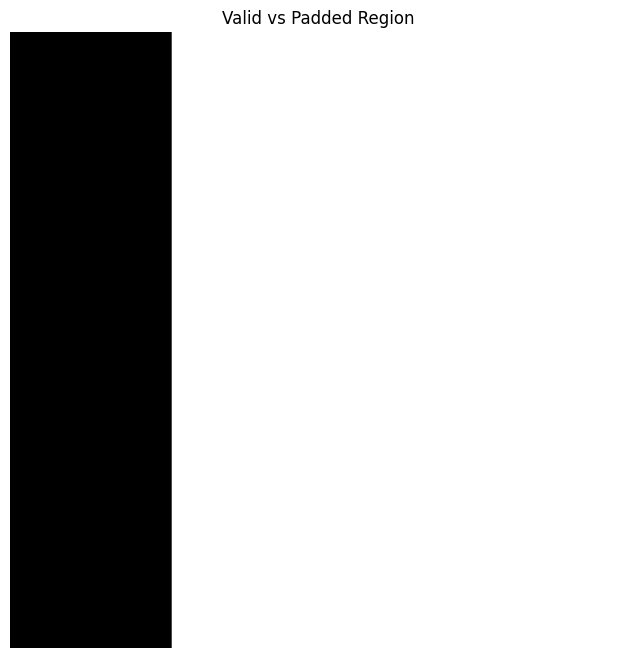

In [27]:
plt.figure(figsize=(8, 8))
plt.imshow(crop_valid, cmap="gray")
plt.title("Valid vs Padded Region")
plt.axis("off")
plt.show()

In [28]:
import cv2
import numpy as np

# Resize validity mask to FunduSegmenter's prediction resolution
crop_valid_224 = cv2.resize(
    crop_valid,
    (224, 224),
    interpolation=cv2.INTER_NEAREST
)

print("Prediction:", pred.shape)
print("Validity mask:", crop_valid_224.shape)

cup_mask = (pred == 0)
disc_mask = (pred == 1)

# Complete optic disc = disc rim + cup
full_od_mask = (pred == 0) | (pred == 1)

background_mask = (pred == 2)

# ============================================================
# CORRECT FUNDUSEGMENTER CLASS MASKS
# ============================================================

cup_mask = (pred == 0)
disc_mask = (pred == 1)
background_mask = (pred == 2)

# Full OD includes both the disc rim and the cup
full_od_mask = cup_mask | disc_mask


# ============================================================
# STATISTICS
# ============================================================

total_cup = np.sum(cup_mask)
total_disc = np.sum(disc_mask)
total_full_od = np.sum(full_od_mask)

valid_cup = np.sum(
    cup_mask & (crop_valid_224 == 1)
)

valid_disc = np.sum(
    disc_mask & (crop_valid_224 == 1)
)

valid_full_od = np.sum(
    full_od_mask & (crop_valid_224 == 1)
)

padding_cup = np.sum(
    cup_mask & (crop_valid_224 == 0)
)

padding_disc = np.sum(
    disc_mask & (crop_valid_224 == 0)
)

padding_full_od = np.sum(
    full_od_mask & (crop_valid_224 == 0)
)


print()
print("=" * 60)
print("FunduSegmenter segmentation statistics")
print("=" * 60)

print("Cup pixels:", total_cup)
print("Disc pixels:", total_disc)
print("Full OD pixels:", total_full_od)

print()
print("Cup inside valid image:", valid_cup)
print("Disc inside valid image:", valid_disc)
print("Full OD inside valid image:", valid_full_od)

print()
print("Cup inside padding:", padding_cup)
print("Disc inside padding:", padding_disc)
print("Full OD inside padding:", padding_full_od)

print()
print(
    "Full OD percentage in padding:",
    100 * padding_full_od / max(total_full_od, 1)
)

print("=" * 60)

# print("Total predicted OD pixels:", total_od)
# print("OD pixels inside valid image:", valid_od)
# print("OD pixels inside padding:", padding_od)

# print(
#     "Percentage of predicted OD in padding:",
#     100 * padding_od / max(total_od, 1)
# )


Prediction: (224, 224)
Validity mask: (224, 224)

FunduSegmenter segmentation statistics
Cup pixels: 48636
Disc pixels: 1217
Full OD pixels: 49853

Cup inside valid image: 35420
Disc inside valid image: 1217
Full OD inside valid image: 36637

Cup inside padding: 13216
Disc inside padding: 0
Full OD inside padding: 13216

Full OD percentage in padding: 26.509939221310653


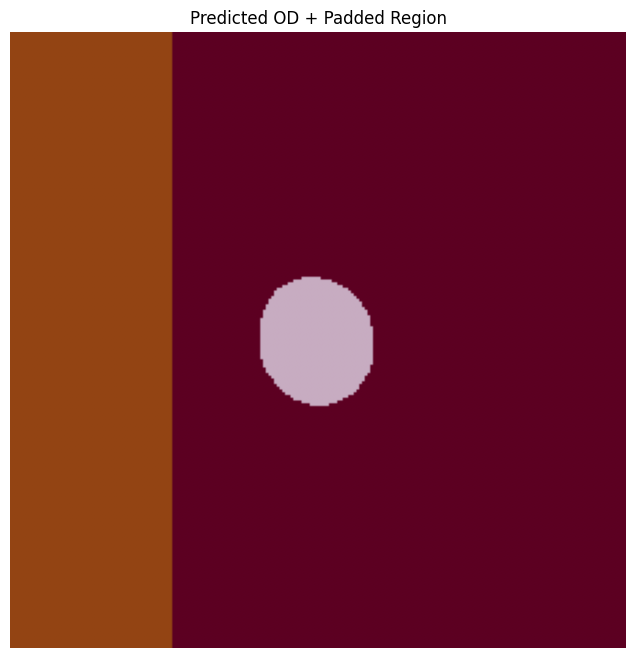

In [29]:
plt.figure(figsize=(8, 8))
plt.imshow(pred == 0, cmap="Reds")
plt.imshow(crop_valid_224 == 0, alpha=0.3)
plt.title("Predicted OD + Padded Region")
plt.axis("off")
plt.show()

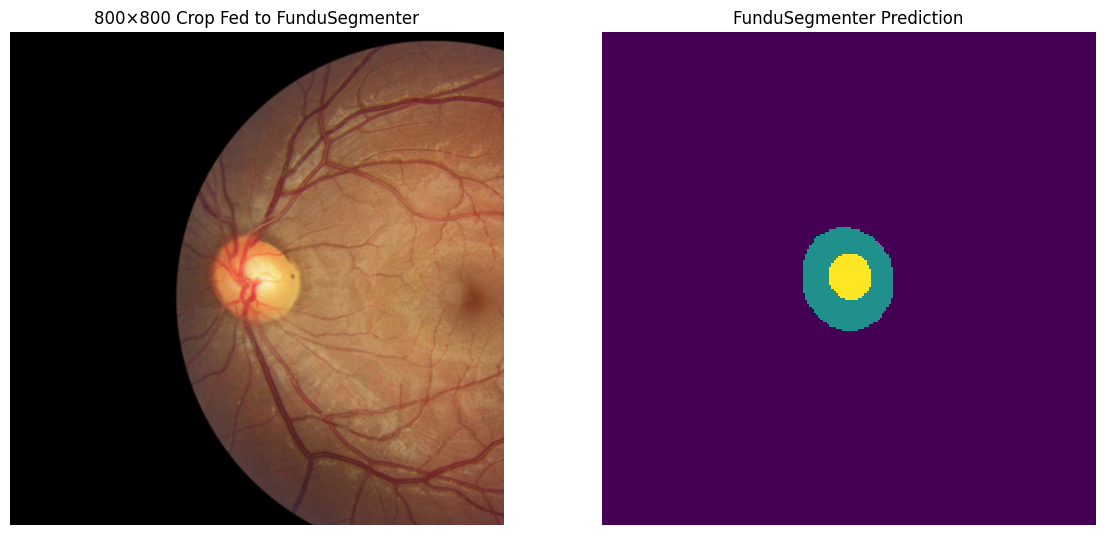

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(cropped_img)
ax[0].set_title("800×800 Crop Fed to FunduSegmenter")
ax[0].axis("off")

ax[1].imshow(pred, interpolation="nearest")
ax[1].set_title("FunduSegmenter Prediction")
ax[1].axis("off")   

plt.show()

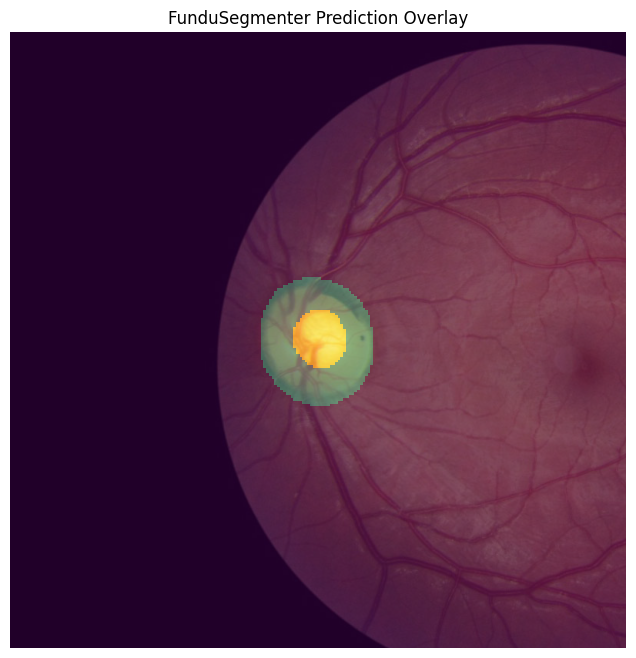

In [31]:
pred_800 = cv2.resize(
    pred.astype(np.uint8),
    (800, 800),
    interpolation=cv2.INTER_NEAREST
)

plt.figure(figsize=(8, 8))
plt.imshow(cropped_img)
plt.imshow(
    pred_800,
    alpha=0.5,
    interpolation="nearest"
)
plt.title("FunduSegmenter Prediction Overlay")
plt.axis("off")
plt.show()

224 mask unique values: [  0 255]
Original image: 951 x 874
Crop coordinates:
left = -210 top = 6 right = 590 bottom = 806

FINAL OD + OC MASK
Original image shape: (874, 951, 3)
Final mask shape: (874, 951)
Unique values: [  0 255]
White pixels: 467067
Black pixels: 364107


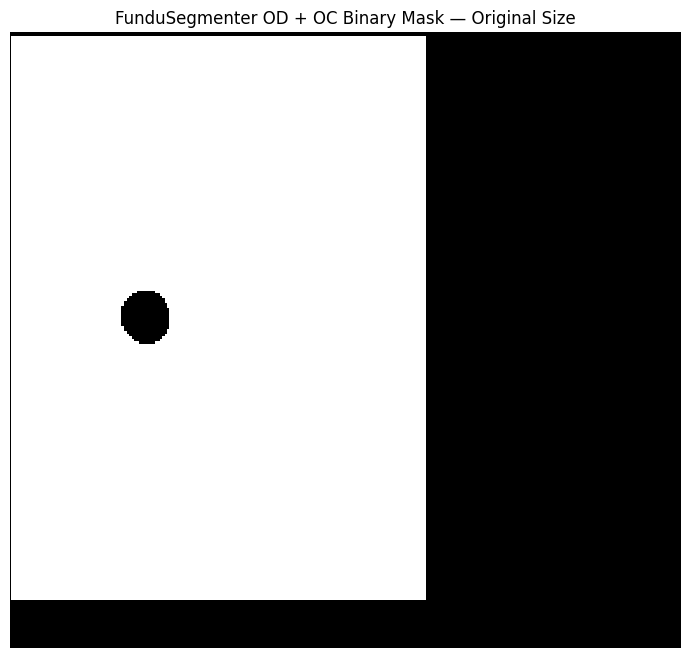

In [35]:
# ============================================================
# FUNDUSEGMENTER PREDICTION → ORIGINAL-SIZE BINARY OD+OC MASK
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# STEP 1
# Keep ONLY the OD + OC predicted region
#
# Based on your current prediction:
#   pred == 0 or pred == 1 = OD + OC
#   pred == 2 = background
# ------------------------------------------------------------

od_oc_224 = (
    (pred == 0) |
    (pred == 1)
).astype(np.uint8)


# ------------------------------------------------------------
# STEP 2
# REMOVE ARTIFICIAL PADDING AT 224x224
#
# This is VERY important.
# Anything outside the real image must be black.
# ------------------------------------------------------------

crop_valid_224 = cv2.resize(
    crop_valid,
    (224, 224),
    interpolation=cv2.INTER_NEAREST
)

od_oc_224[
    crop_valid_224 == 0
] = 0


# ------------------------------------------------------------
# STEP 3
# Convert to true binary mask
#
# OD + OC = 255 WHITE
# Background = 0 BLACK
# ------------------------------------------------------------

od_oc_224 = (
    od_oc_224 * 255
).astype(np.uint8)


print("224 mask unique values:",
      np.unique(od_oc_224))


# ------------------------------------------------------------
# STEP 4
# Resize 224x224 → 800x800
#
# NEAREST is essential because this is a binary mask.
# ------------------------------------------------------------

od_oc_800 = cv2.resize(
    od_oc_224,
    (800, 800),
    interpolation=cv2.INTER_NEAREST
)


# ------------------------------------------------------------
# STEP 5
# Apply the ORIGINAL 800x800 validity mask AGAIN
#
# This guarantees that resizing cannot introduce white
# pixels into the artificial padded area.
# ------------------------------------------------------------

od_oc_800[
    crop_valid == 0
] = 0


# ------------------------------------------------------------
# STEP 6
# Get original image dimensions
# ------------------------------------------------------------

original_h, original_w = img_rgb.shape[:2]

print("Original image:",
      original_w, "x", original_h)


# ------------------------------------------------------------
# STEP 7
# Calculate where the 800x800 crop came from
# in the ORIGINAL image
# ------------------------------------------------------------

cx, cy = centre

crop_size = 800
half = crop_size // 2

left = cx - half
top = cy - half

right = left + crop_size
bottom = top + crop_size

print("Crop coordinates:")
print(
    "left =", left,
    "top =", top,
    "right =", right,
    "bottom =", bottom
)


# ------------------------------------------------------------
# STEP 8
# Create a completely BLACK original-size mask
# ------------------------------------------------------------

final_od_mask = np.zeros(
    (original_h, original_w),
    dtype=np.uint8
)


# ------------------------------------------------------------
# STEP 9
# Determine which part of the 800x800 crop actually
# belongs to the ORIGINAL image
# ------------------------------------------------------------

src_left = max(left, 0)
src_top = max(top, 0)

src_right = min(right, original_w)
src_bottom = min(bottom, original_h)


# ------------------------------------------------------------
# STEP 10
# Corresponding coordinates inside the 800x800 mask
# ------------------------------------------------------------

crop_left = src_left - left
crop_top = src_top - top

crop_right = crop_left + (
    src_right - src_left
)

crop_bottom = crop_top + (
    src_bottom - src_top
)


# ------------------------------------------------------------
# STEP 11
# Paste ONLY the valid region into original image
# ------------------------------------------------------------

final_od_mask[
    src_top:src_bottom,
    src_left:src_right
] = od_oc_800[
    crop_top:crop_bottom,
    crop_left:crop_right
]


# ------------------------------------------------------------
# STEP 12
# Force exact binary values again
# ------------------------------------------------------------

final_od_mask = np.where(
    final_od_mask > 127,
    255,
    0
).astype(np.uint8)


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print()
print("=" * 60)
print("FINAL OD + OC MASK")
print("=" * 60)

print("Original image shape:",
      img_rgb.shape)

print("Final mask shape:",
      final_od_mask.shape)

print("Unique values:",
      np.unique(final_od_mask))

print("White pixels:",
      np.sum(final_od_mask == 255))

print("Black pixels:",
      np.sum(final_od_mask == 0))

print("=" * 60)


# ------------------------------------------------------------
# DISPLAY FINAL MASK
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(
    final_od_mask,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest"
)

plt.title(
    "FunduSegmenter OD + OC Binary Mask — Original Size"
)

plt.axis("off")

plt.show()

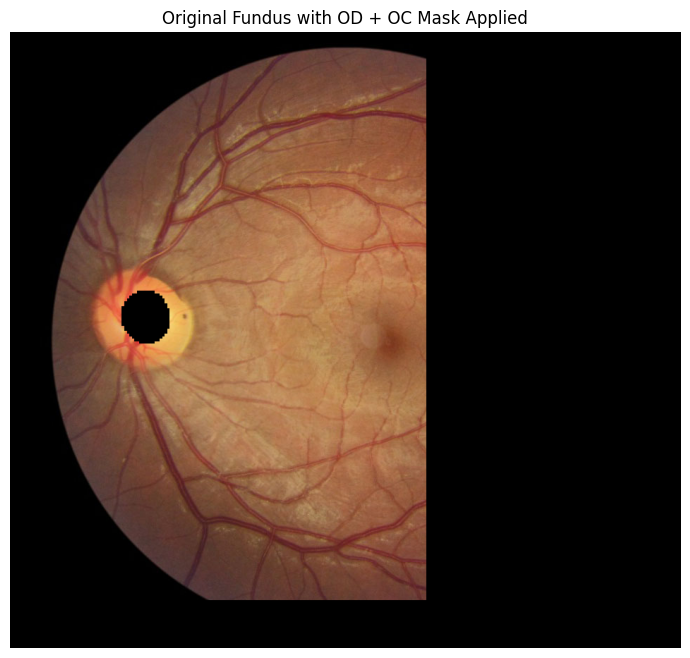

In [36]:
# ============================================================
# APPLY BINARY OD+OC MASK TO ORIGINAL FUNDUS IMAGE
# ============================================================

# final_od_mask:
#   255 = OD + OC
#   0   = background

# Make sure mask and image have exactly the same dimensions
assert final_od_mask.shape[:2] == img_rgb.shape[:2], (
    f"Size mismatch: "
    f"mask={final_od_mask.shape}, "
    f"image={img_rgb.shape}"
)

# Keep original RGB pixels where mask is white
# Everything else becomes black
masked_original = cv2.bitwise_and(
    img_rgb,
    img_rgb,
    mask=final_od_mask
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(masked_original)

plt.title("Original Fundus with OD + OC Mask Applied")

plt.axis("off")

plt.show()

In [37]:
# ============================================================
# FUNDUSEGMENTER PREDICTION -> ORIGINAL SIZE OD+OC MASK
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. pred contains:
#    background = 0
#    OD/OC      = non-zero classes
# ------------------------------------------------------------

full_od_mask_224 = (
    pred != 0
).astype(np.uint8)

print("Prediction classes:", np.unique(pred))
print("OD+OC pixels:", np.sum(full_od_mask_224))


# ------------------------------------------------------------
# 2. Remove artificial padding at 224x224
# ------------------------------------------------------------

crop_valid_224 = cv2.resize(
    crop_valid,
    (224, 224),
    interpolation=cv2.INTER_NEAREST
)

full_od_mask_224[
    crop_valid_224 == 0
] = 0


# ------------------------------------------------------------
# 3. Convert:
#       OD + OC = WHITE
#       Background = BLACK
# ------------------------------------------------------------

full_od_mask_224 = (
    full_od_mask_224 * 255
).astype(np.uint8)


# ------------------------------------------------------------
# 4. Resize 224 -> 800
#    IMPORTANT: NEAREST for segmentation masks
# ------------------------------------------------------------

full_od_mask_800 = cv2.resize(
    full_od_mask_224,
    (800, 800),
    interpolation=cv2.INTER_NEAREST
)


# ------------------------------------------------------------
# 5. Apply validity mask AGAIN after resizing
# ------------------------------------------------------------

full_od_mask_800[
    crop_valid == 0
] = 0


# ------------------------------------------------------------
# 6. Create BLACK mask at original image size
# ------------------------------------------------------------

original_h, original_w = img_rgb.shape[:2]

final_od_mask = np.zeros(
    (original_h, original_w),
    dtype=np.uint8
)


# ------------------------------------------------------------
# 7. Get exact 800x800 crop position
# ------------------------------------------------------------

cx, cy = centre

crop_size = 800
half = crop_size // 2

left = cx - half
top = cy - half

right = left + crop_size
bottom = top + crop_size


# ------------------------------------------------------------
# 8. Find portion of crop that belongs to original image
# ------------------------------------------------------------

src_left = max(left, 0)
src_top = max(top, 0)

src_right = min(right, original_w)
src_bottom = min(bottom, original_h)


# ------------------------------------------------------------
# 9. Corresponding coordinates inside 800x800 mask
# ------------------------------------------------------------

dst_left = src_left - left
dst_top = src_top - top

dst_right = dst_left + (
    src_right - src_left
)

dst_bottom = dst_top + (
    src_bottom - src_top
)


# ------------------------------------------------------------
# 10. Paste OD+OC into original coordinates
# ------------------------------------------------------------

final_od_mask[
    src_top:src_bottom,
    src_left:src_right
] = full_od_mask_800[
    dst_top:dst_bottom,
    dst_left:dst_right
]


# ------------------------------------------------------------
# 11. Ensure EXACTLY binary
# ------------------------------------------------------------

final_od_mask = np.where(
    final_od_mask > 127,
    255,
    0
).astype(np.uint8)


# ------------------------------------------------------------
# 12. CHECK
# ------------------------------------------------------------

print()
print("Original image:", img_rgb.shape)
print("Final mask:", final_od_mask.shape)
print("Unique values:", np.unique(final_od_mask))
print("White pixels:", np.sum(final_od_mask == 255))
print("Black pixels:", np.sum(final_od_mask == 0))

Prediction classes: [0 1 2]
OD+OC pixels: 1540

Original image: (874, 951, 3)
Final mask: (874, 951)
Unique values: [  0 255]
White pixels: 19621
Black pixels: 811553


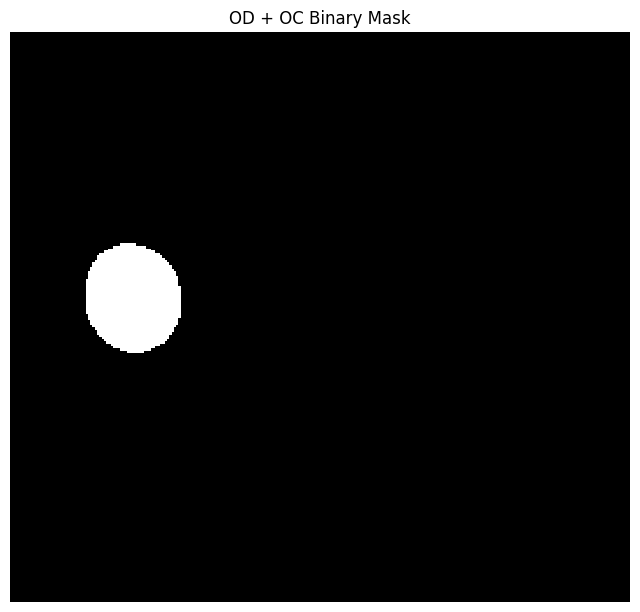

In [38]:
plt.figure(figsize=(8, 8))

plt.imshow(
    final_od_mask,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest"
)

plt.title("OD + OC Binary Mask")
plt.axis("off")

plt.show()

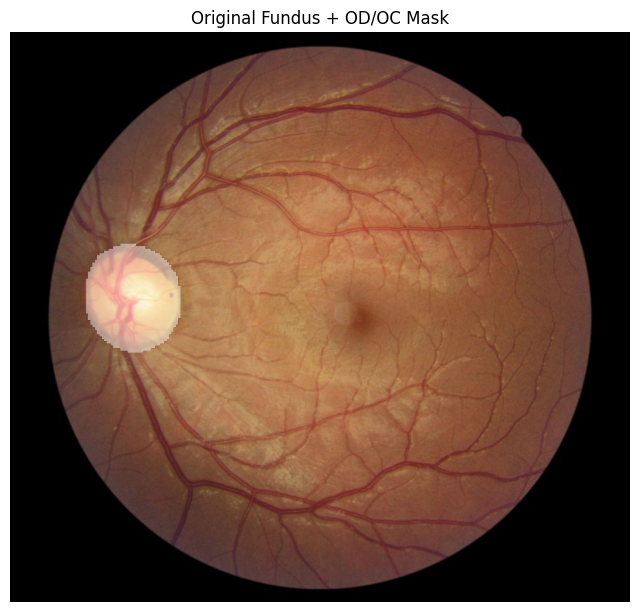

In [40]:
# ============================================================
# ORIGINAL FUNDUS + OD/OC MASK WITH TRANSPARENCY
# ============================================================

plt.figure(figsize=(8, 8))

# Background: original fundus
plt.imshow(img_rgb)

# OD + OC mask:
# Only white pixels (255) are displayed.
# Black pixels are made transparent.
overlay = np.ma.masked_where(
    final_od_mask == 0,
    final_od_mask
)

plt.imshow(
    overlay,
    cmap="gray",
    alpha=0.45,       # transparency
    vmin=0,
    vmax=255
)

plt.title("Original Fundus + OD/OC Mask")

plt.axis("off")

plt.show()

In [32]:
# ============================================================
# FUNDUSEGMENTER → SA-UNET STYLE OD+OC BINARY MASK
# ============================================================

def restore_fundusegmenter_od_mask(
    pred,
    centre,
    original_shape,
    crop_size=800
):
    """
    Convert FunduSegmenter prediction into a binary
    OD+OC mask at the original image resolution.

    FunduSegmenter classes:
        0 = OC / cup
        1 = OD / disc
        2 = background

    Output:
        255 = OD + OC
        0   = background
    """

    original_h, original_w = original_shape[:2]

    # --------------------------------------------------
    # 1. Combine OD + OC
    # --------------------------------------------------

    od_oc_224 = (
        (pred == 0) |
        (pred == 1)
    ).astype(np.uint8)

    # --------------------------------------------------
    # 2. Resize 224x224 → 800x800
    # --------------------------------------------------

    od_oc_800 = cv2.resize(
        od_oc_224,
        (crop_size, crop_size),
        interpolation=cv2.INTER_NEAREST
    )

    # --------------------------------------------------
    # 3. Calculate original crop coordinates
    # --------------------------------------------------

    cx, cy = centre
    half = crop_size // 2

    left = cx - half
    top = cy - half
    right = left + crop_size
    bottom = top + crop_size

    # --------------------------------------------------
    # 4. Create original-resolution black mask
    # --------------------------------------------------

    mask_original = np.zeros(
        (original_h, original_w),
        dtype=np.uint8
    )

    # --------------------------------------------------
    # 5. Find valid image region
    # --------------------------------------------------

    src_left = max(left, 0)
    src_top = max(top, 0)

    src_right = min(right, original_w)
    src_bottom = min(bottom, original_h)

    # --------------------------------------------------
    # 6. Corresponding coordinates inside 800x800 crop
    # --------------------------------------------------

    dst_left = src_left - left
    dst_top = src_top - top

    dst_right = dst_left + (src_right - src_left)
    dst_bottom = dst_top + (src_bottom - src_top)

    # --------------------------------------------------
    # 7. Paste only VALID predicted pixels
    # --------------------------------------------------

    mask_original[
        src_top:src_bottom,
        src_left:src_right
    ] = od_oc_800[
        dst_top:dst_bottom,
        dst_left:dst_right
    ]

    # --------------------------------------------------
    # 8. Convert to SA-UNet style 0/255 mask
    # --------------------------------------------------

    mask_original = (
        mask_original * 255
    ).astype(np.uint8)

    return mask_original

In [33]:
# ============================================================
# TEST ON CURRENT IMAGE
# ============================================================

od_mask_original = restore_fundusegmenter_od_mask(
    pred=pred,
    centre=centre,
    original_shape=img_rgb.shape,
    crop_size=800
)

print("Original image:", img_rgb.shape)
print("OD mask:", od_mask_original.shape)
print("Unique values:", np.unique(od_mask_original))
print(
    "White pixels:",
    np.sum(od_mask_original == 255)
)
print(
    "Black pixels:",
    np.sum(od_mask_original == 0)
)

Original image: (874, 951, 3)
OD mask: (874, 951)
Unique values: [  0 255]
White pixels: 467867
Black pixels: 363307


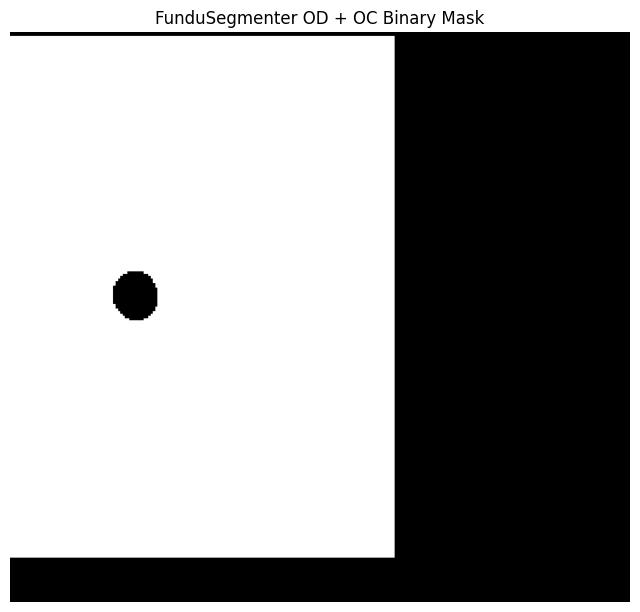

In [34]:
plt.figure(figsize=(8, 8))

plt.imshow(od_mask_original, cmap="gray")

plt.title("FunduSegmenter OD + OC Binary Mask")
plt.axis("off")

plt.show()